# Clustering Tuning Explorer

Esplorazione interattiva di sweep di tuning **già eseguite** (`clustering.py --fine_tuning true`) —
non rifà né sostituisce la sweep, legge solo `tuning_results.csv` + le diagnostiche standalone
(dendrogrammi, interclass distance matrix, eigengap...) già scritte su disco.
Nessuna selezione automatica di `k`/iperparametri qui (`code_standards.md` §0) — è uno strumento
di lettura, la decisione resta umana.

Diverso da `clustering_evaluation.ipynb` (che confronta run **prodotte**, `fine_tuning: false`):
questo notebook lavora sulla fase *precedente*, la scelta di `k` dentro una sweep di tuning —
vedi `knowledge/dim_reduction_clustering/clustering_tuning_guide.md` per come leggere ogni indice.

**Le uniche celle da modificare per cambiare cosa si guarda sono `RUN_DIRS` (sezione 1) e
`IMAGE_NAME` (sezione 2).**

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as clustering_evaluation.ipynb / temp/*/run_prototype.py.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

## 1. Seleziona le run da confrontare

`RUN_DIRS` è la lista delle cartelle `<metodo>/tuning/<tag>/` da mettere a confronto - ognuna deve
contenere un proprio `tuning_results.csv` (e, per la sezione 2, le stesse diagnostiche standalone).
Confrontare run con `tuning_grid` diversi tra loro è permesso (le colonne extra restano `NaN` dove
non applicabili), ma ha senso solo se le run condividono lo stesso metodo - il notebook non lo
impone, è responsabilità di chi lo usa.

Esempio sotto: le 3 dimensionalità dell'embedding UMAP euclidean per agglomerative
(27-08_s1.1_euclidean_n2/n3/n10).

In [2]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n10",
]

for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

In [3]:
def load_tuning_results(run_dirs: list[Path]) -> pd.DataFrame:
    """Reads tuning_results.csv from each run dir and concatenates them, tagged by a
    `run` column (the run dir's own name, e.g. "27-08_s1.1_euclidean_n10")."""
    frames = []
    for run_dir in run_dirs:
        csv_path = run_dir / "tuning_results.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(f"no tuning_results.csv in {run_dir}")
        df = pd.read_csv(csv_path)
        df.insert(0, "run", run_dir.name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


results = load_tuning_results(RUN_DIRS)
print(f"{len(results)} righe, run: {sorted(results['run'].unique())}")
results

210 righe, run: ['27-08_s1.1_euclidean_n10', '27-08_s1.1_euclidean_n2', '27-08_s1.1_euclidean_n3']


,run,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
0,27-08_s1.1_euclidean_n2,2,ward,euclidean,0.455511,0.0,907.594908,0.738191
1,27-08_s1.1_euclidean_n2,2,average,euclidean,0.455511,0.0,907.594908,0.738191
2,27-08_s1.1_euclidean_n2,2,average,cosine,0.728186,0.0,NaN,NaN
3,27-08_s1.1_euclidean_n2,2,average,manhattan,0.416929,0.0,NaN,NaN
4,27-08_s1.1_euclidean_n2,2,complete,euclidean,0.348526,0.0,896.337422,0.984544
...,...,...,...,...,...,...,...,...
205,27-08_s1.1_euclidean_n10,10,complete,cosine,0.482055,0.0,NaN,NaN
206,27-08_s1.1_euclidean_n10,10,complete,manhattan,0.370977,0.0,NaN,NaN
207,27-08_s1.1_euclidean_n10,10,single,euclidean,-0.439265,0.0,1.304663,1.885256
208,27-08_s1.1_euclidean_n10,10,single,cosine,-0.683206,0.0,NaN,NaN


Da qui in poi `results` è un DataFrame pandas normale - filtralo/ordinalo come preferisci.
Un paio di esempi (decommentare/adattare):

In [4]:
# Solo una metrica, ordinato per silhouette decrescente:
# results[results["metric"] == "euclidean"].sort_values("silhouette", ascending=False)

# Solo un linkage, per confrontare le 3 dimensionalità fianco a fianco:
# results[results["linkage"] == "average"].sort_values(["n_clusters", "run"])

# Migliore per (run, metric), scartando single linkage:
results[results["linkage"] != "single"].sort_values("silhouette", ascending=False).groupby(["run", "metric"]).head(1)

,run,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
12,27-08_s1.1_euclidean_n2,3,average,cosine,0.750781,0.0,NaN,NaN
75,27-08_s1.1_euclidean_n3,2,complete,cosine,0.730168,0.0,NaN,NaN
162,27-08_s1.1_euclidean_n10,4,average,cosine,0.665396,0.0,NaN,NaN
31,27-08_s1.1_euclidean_n2,5,average,euclidean,0.496595,0.0,1384.734553,0.618362
43,27-08_s1.1_euclidean_n2,6,average,manhattan,0.491239,0.0,NaN,NaN
83,27-08_s1.1_euclidean_n3,3,average,manhattan,0.487295,0.0,NaN,NaN
80,27-08_s1.1_euclidean_n3,3,ward,euclidean,0.481611,0.0,1460.136715,0.784455
164,27-08_s1.1_euclidean_n10,4,complete,euclidean,0.445590,0.0,1006.928463,0.787231
163,27-08_s1.1_euclidean_n10,4,average,manhattan,0.440317,0.0,NaN,NaN


## 2. Confronta immagini diagnostiche

`IMAGE_NAME` è il nome file della diagnostica da confrontare fianco a fianco sulle stesse
`RUN_DIRS` selezionate sopra (es. `dendrogram_average.png`, `interclass_distance_matrix.png` per
agglomerative; `eigengap_plot.png` per spectral - vedi `clustering_tuning_guide.md` per l'elenco
completo per metodo). Cambia solo questa variabile e ri-esegui la cella per guardare un'altra
diagnostica sulle stesse run.

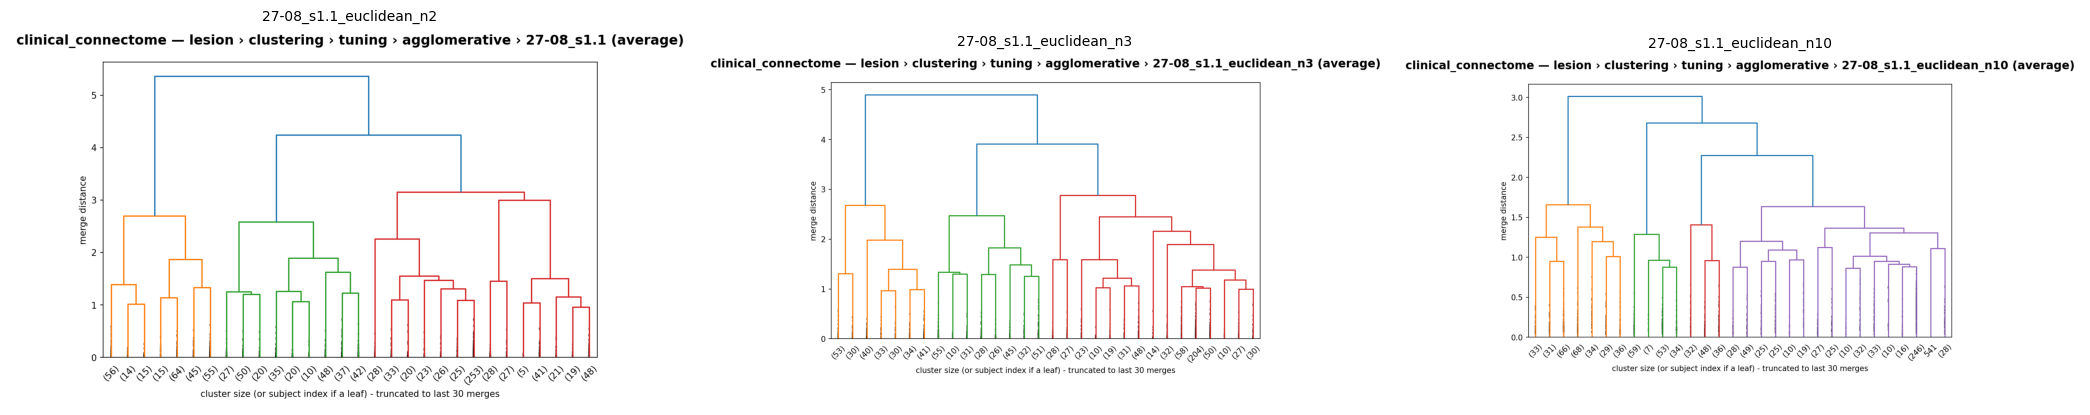

In [5]:
def show_run_images(run_dirs: list[Path], image_name: str) -> None:
    """Displays the same-named diagnostic image side by side, one column per run dir.
    Raises if a run is missing that file rather than silently skipping it - a missing
    diagnostic (e.g. asking for a dendrogram on a non-agglomerative run) is a usage
    error to fix, not something to paper over."""
    fig, axes = plt.subplots(1, len(run_dirs), figsize=(7 * len(run_dirs), 7))
    axes = [axes] if len(run_dirs) == 1 else axes
    for ax, run_dir in zip(axes, run_dirs):
        image_path = run_dir / image_name
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_name!r} not found in {run_dir}")
        ax.imshow(plt.imread(image_path))
        ax.set_title(run_dir.name, fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


IMAGE_NAME = "dendrogram_average.png"
show_run_images(RUN_DIRS, IMAGE_NAME)

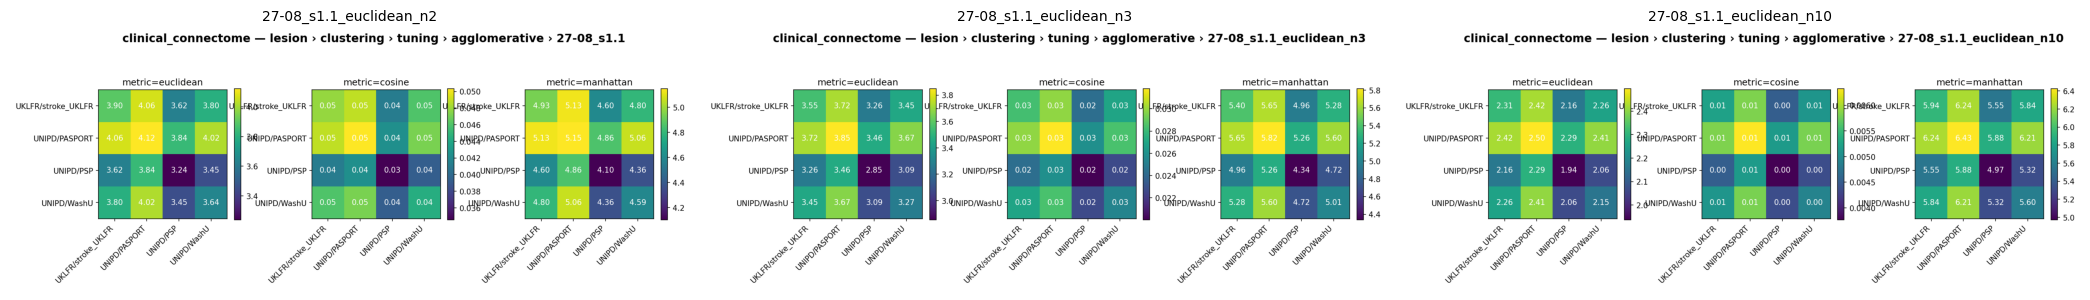

In [6]:
IMAGE_NAME = "interclass_distance_matrix.png"
show_run_images(RUN_DIRS, IMAGE_NAME)